<a href="https://colab.research.google.com/github/ArletteT3/Handwritten-Digit-Recognition-with-CNN-MNIST-Colab-Project/blob/main/Handwritten_Digit_CNN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digit Recognition with CNN (MNIST) — Colab Project

**Author:** Arlette Torres  
**Course:** CPSC 4330-01/5330-01 Multimedia Processing  
**Instructor:** Prof. JIANGJIANG (JANE) LIU  
**Date:** 2025-11-05

This notebook implements a Convolutional Neural Network (CNN) for **handwritten digit recognition** using the **MNIST** dataset.  
It follows the style of TensorFlow’s tutorials on CNNs and image classification, adapted to meet project requirements (80/20 split, screenshots of 10 images, testing results, and a short, commented source).

**Dataset:** [MNIST (Yann LeCun)](http://yann.lecun.com/exdb/mnist/) — 70,000 grayscale 28×28 digit images (0–9).  
**Frameworks:** TensorFlow / Keras, NumPy, Matplotlib, scikit-learn (for confusion matrix).

> Tip: If you open this notebook in **Google Colab**, click **Runtime → Change runtime type → GPU** to speed up training.


## 1) Setup

In [ ]:

# @title Install / Import (Colab-safe)
# If running on Colab, the required packages are pre-installed.
# This cell simply imports what we need.

import os, sys, time, pathlib, itertools
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# For evaluation visuals
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # Colab has seaborn; for pretty confusion matrix

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Export folder for saving images/results for your submission
EXPORT_DIR = pathlib.Path("exports")
EXPORT_DIR.mkdir(exist_ok=True)
print("Saving exports to:", EXPORT_DIR.resolve())


TensorFlow: 2.19.0
Num GPUs Available: 1
Saving exports to: /content/exports


## 2) Load & Prepare the Dataset (80/20 split)

In [ ]:

# @title Load MNIST and make an 80/20 train/test split
# Keras provides MNIST, but we still save a local copy for your submission.
# We also show exactly where the dataset came from (see README).

# Load MNIST: (train_images, train_labels), (test_images, test_labels)
# The official Keras MNIST split is 60k/10k; we will recombine and make our own 80/20 split.
(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = keras.datasets.mnist.load_data()

images = np.concatenate([mnist_train_images, mnist_test_images], axis=0)
labels = np.concatenate([mnist_train_labels, mnist_test_labels], axis=0)

# Normalize pixel values to [0,1]
images = images.astype("float32") / 255.0

# Add channel dimension so shape is (N, 28, 28, 1)
images = np.expand_dims(images, axis=-1)

# 80/20 split
N = images.shape[0]
split = int(0.8 * N)
x_train, y_train = images[:split], labels[:split]
x_test,  y_test  = images[split:], labels[split:]

print("Train shape:", x_train.shape, y_train.shape)
print("Test  shape:", x_test.shape, y_test.shape)

# Save dataset (to satisfy 'dataset files' requirement)
np.savez_compressed(EXPORT_DIR / "mnist_8020.npz",
                    x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
print("Saved dataset arrays to exports/mnist_8020.npz")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (56000, 28, 28, 1) (56000,)
Test  shape: (14000, 28, 28, 1) (14000,)
Saved dataset arrays to exports/mnist_8020.npz


## 3) Visualize Ten Sample Images (and Save Screenshot)

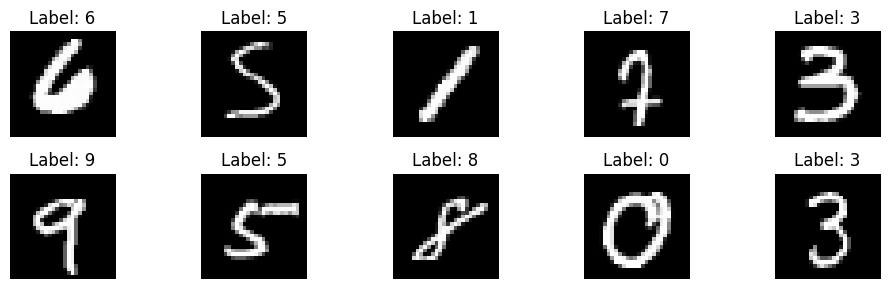

Saved screenshot to: exports/ten_sample_images.png


In [ ]:

# @title Show and save a 10-image grid
plt.figure(figsize=(10, 3))
idxs = np.random.choice(len(x_train), size=10, replace=False)
for i, idx in enumerate(idxs, start=1):
    plt.subplot(2, 5, i)
    plt.imshow(x_train[idx].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "ten_sample_images.png", dpi=200)
plt.show()

print("Saved screenshot to:", EXPORT_DIR / "ten_sample_images.png")


## 4) Build a CNN (inspired by TF CNN tutorial)

In [ ]:

# @title Define the CNN model
# This architecture is small but effective for MNIST, following common CNN patterns:
# Conv -> Conv -> Pool -> Dropout -> Conv -> Pool -> Flatten -> Dense -> Dropout -> Softmax

def build_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,690 (1.92 MB)

 Trainable params: 503,690 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

## 5) Train the Model

In [ ]:

# @title Train (tweak epochs for faster or better results)
EPOCHS = 8  # Colab-friendly; you can raise to ~12–15 for ~99% test accuracy
BATCH_SIZE = 128

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# Save model
model.save(EXPORT_DIR / "cnn_mnist.keras")
print("Saved trained model to:", EXPORT_DIR / "cnn_mnist.keras")


Epoch 1/8
394/394 - 15s - 38ms/step - accuracy: 0.9106 - loss: 0.2817 - val_accuracy: 0.9821 - val_loss: 0.0630
Epoch 2/8
394/394 - 3s - 8ms/step - accuracy: 0.9725 - loss: 0.0946 - val_accuracy: 0.9861 - val_loss: 0.0466
Epoch 3/8
394/394 - 3s - 8ms/step - accuracy: 0.9795 - loss: 0.0681 - val_accuracy: 0.9895 - val_loss: 0.0367
Epoch 4/8
394/394 - 3s - 8ms/step - accuracy: 0.9839 - loss: 0.0547 - val_accuracy: 0.9905 - val_loss: 0.0298
Epoch 5/8
394/394 - 3s - 9ms/step - accuracy: 0.9864 - loss: 0.0451 - val_accuracy: 0.9911 - val_loss: 0.0298
Epoch 6/8
394/394 - 3s - 8ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9921 - val_loss: 0.0324
Epoch 7/8
394/394 - 3s - 8ms/step - accuracy: 0.9896 - loss: 0.0351 - val_accuracy: 0.9914 - val_loss: 0.0264
Epoch 8/8
394/394 - 3s - 8ms/step - accuracy: 0.9914 - loss: 0.0290 - val_accuracy: 0.9912 - val_loss: 0.0335
Saved trained model to: exports/cnn_mnist.keras


## 6) Evaluate on the 20% Test Set (and Save Results)

Test Accuracy: 0.9933  |  Test Loss: 0.0285


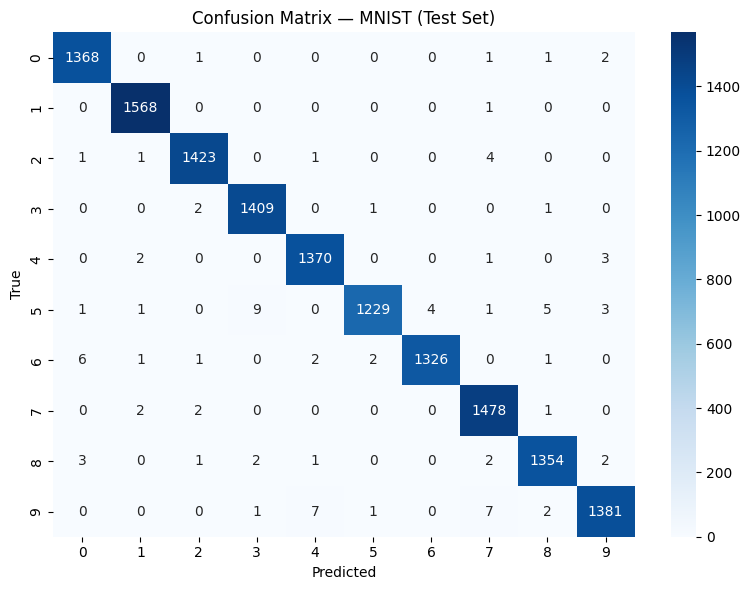

              precision    recall  f1-score   support

           0     0.9920    0.9964    0.9942      1373
           1     0.9956    0.9994    0.9975      1569
           2     0.9951    0.9951    0.9951      1430
           3     0.9916    0.9972    0.9944      1413
           4     0.9920    0.9956    0.9938      1376
           5     0.9968    0.9808    0.9887      1253
           6     0.9970    0.9903    0.9936      1339
           7     0.9886    0.9966    0.9926      1483
           8     0.9919    0.9919    0.9919      1365
           9     0.9928    0.9871    0.9900      1399

    accuracy                         0.9933     14000
   macro avg     0.9933    0.9930    0.9932     14000
weighted avg     0.9933    0.9933    0.9933     14000

Saved testing results to: exports/testing_results.txt
Saved confusion matrix image to: exports/confusion_matrix.png


In [ ]:

# @title Test evaluation and reports
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}")

# Predictions for confusion matrix
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — MNIST (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# Classification report
report = classification_report(y_test, y_pred, digits=4)
print(report)

# Save textual report
with open(EXPORT_DIR / "testing_results.txt", "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\nTest Loss: {test_loss:.4f}\n\n")
    f.write(report)

print("Saved testing results to:", EXPORT_DIR / "testing_results.txt")
print("Saved confusion matrix image to:", EXPORT_DIR / "confusion_matrix.png")


\## 7) How to Run Every Cell in Colab


- Click the **"Open in Colab"** button (if present where you uploaded this notebook), or upload this notebook to Colab manually.  
- Then use the **play ▶ buttons** on the top-left of each cell to execute them in order.  
- Make sure you run **Setup**, then **Load Data**, then **Train**, then **Evaluate**.
- All required submission artifacts are saved into the `exports/` folder.


## 8) References


- TensorFlow: *Convolutional Neural Network Tutorial* and *Image Classification Tutorial*  
- Dataset: MNIST — http://yann.lecun.com/exdb/mnist/  
- Paper (optional background): Bendib et al., **Handwritten Digit Recognition Using Deep CNN**, ISPR'20.
